1. Set Up & Installation

In [ ]:
# Core Libraries
%pip install "numpy<2.0" transformers accelerate datasets --quiet

# Image Processing & Augmentation Libraries
%pip install albumentations opencv-python pillow --quiet

# Visualization & Eval Libaries
%pip install evaluate matplotlib tqdm pycocotools --quiet

Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Archive Libraries
import os
import json
import re
from pathlib import Path

# Image Processing Libraries
from PIL import Image #change .jpg to matrix
import numpy as np #same func as Image
import albumentations as A #for data augmentation
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Core AI Libraries (PyTorch)
import torch
from torch import nn
from torch import optim
import torch.optim as optim

# Hugging Face Management Libraries
from datasets import Dataset, DatasetDict
from transformers import (
    AutoImageProcessor, #resize images
    RTDetrForObjectDetection, #architecture model
    RTDetrImageProcessor,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback #stop training if parameters are met
)

# Training Visualization Libraries
import time
import math
import random #to show before vs after augmented images
from tqdm import tqdm #to show progress bar

# Mathematical Evaluation Libraries
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

d:\Skripsi_Raphaela\rt_detr\program\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2. Load Model & Processor

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
MODEL_NAME = "PekingU/rtdetr_r18vd"
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

id2label = {
    0: "Excavator",
    1: "Pillar",
    2: "Rock",
    3: "Traffic Cone",
    4: "Truck"
}

label2id = {v: k for k, v in id2label.items()}

model = RTDetrForObjectDetection.from_pretrained(
    MODEL_NAME,
    num_labels=5,
    id2label=id2label, #convert id (0-4) to class label for visualization
    label2id=label2id, #locked label mapping
    ignore_mismatched_sizes=True
)

model.to(device)

The image processor of type `RTDetrImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 526/526 [00:00<00:00, 1426.02it/s, Materializing param=model.encoder_input_proj.2.1.weight]                                                 
RTDetrForObjectDetection LOAD REPORT from: PekingU/rtdetr_r18vd
Key                                        | Status   |                                                                                        
-------------------------------------------+----------+----------------------------------------------------------------------------------------
model.enc_score_head.bias                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([5])          
model.decoder.c

RTDetrForObjectDetection(
  (model): RTDetrModel(
    (backbone): RTDetrConvEncoder(
      (model): RTDetrResNetBackbone(
        (embedder): RTDetrResNetEmbeddings(
          (embedder): Sequential(
            (0): RTDetrResNetConvLayer(
              (convolution): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
              (normalization): RTDetrFrozenBatchNorm2d()
              (activation): ReLU()
            )
            (1): RTDetrResNetConvLayer(
              (convolution): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (normalization): RTDetrFrozenBatchNorm2d()
              (activation): ReLU()
            )
            (2): RTDetrResNetConvLayer(
              (convolution): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (normalization): RTDetrFrozenBatchNorm2d()
              (activation): ReLU()
            )
          )
          (pooler): MaxPool2d(

3. Individual Dataset Preparation

In [ ]:
ANNOTATIONS_DIR = r"D:\Skripsi_Raphaela\rt_detr\dataset\split_dataset\annotations"
TRAIN_DIR = r"D:\Skripsi_Raphaela\rt_detr\dataset\split_dataset\train"
VAL_DIR   = r"D:\Skripsi_Raphaela\rt_detr\dataset\split_dataset\val"
TEST_DIR  = r"D:\Skripsi_Raphaela\rt_detr\dataset\split_dataset\test"

TRAIN_ANN = os.path.join(ANNOTATIONS_DIR, "train.json")
VAL_ANN   = os.path.join(ANNOTATIONS_DIR, "val.json")
TEST_ANN = os.path.join(ANNOTATIONS_DIR, "test.json")

Parsing COCO to List of Dicts

In [ ]:
def build_dataset_from_coco(coco_json_path, images_dir):
    with open(coco_json_path, "r", encoding="utf-8") as f:
        coco = json.load(f)

    # index annotations by image_id
    ann_by_img = {}
    for ann in coco.get("annotations", []):
        img_id = ann["image_id"]
        ann_by_img.setdefault(img_id, []).append({
            "bbox": ann["bbox"],              # COCO format: [x,y,w,h]
            "category_id": ann["category_id"],
            "iscrowd": ann.get("iscrowd", 0)
        })

    # map image entries
    examples = []
    for img in coco.get("images", []):
        img_id = img["id"]
        file_name = img.get("file_name")
        # build absolute path
        abs_path = os.path.join(images_dir, file_name)
        if not os.path.exists(abs_path):
            # try other possibilities (just in case)
            alt = os.path.join(images_dir, os.path.basename(file_name))
            if os.path.exists(alt):
                abs_path = alt
            else:
                # skip missing image
                print(f"Warning: file not found: {abs_path}, skipping.")
                continue

        examples.append({
            "image_id": img_id,
            "file_name": abs_path,
            "height": img.get("height"),
            "width": img.get("width"),
            "annotations": ann_by_img.get(img_id, [])
        })
    return examples

train_list = build_dataset_from_coco(TRAIN_ANN, TRAIN_DIR)
val_list   = build_dataset_from_coco(VAL_ANN, VAL_DIR)
test_list = build_dataset_from_coco(TEST_ANN, TEST_DIR)

print(f"Train images parsed: {len(train_list)}")
print(f"Val images parsed: {len(val_list)}")
print(f"Test images parsed: {len(test_list)}")

hf_train = Dataset.from_list(train_list)
hf_val   = Dataset.from_list(val_list)
hf_test  = Dataset.from_list(test_list)
datasets = DatasetDict({"train": hf_train, "validation": hf_val, "test": hf_test})

Train images parsed: 1008
Val images parsed: 288
Test images parsed: 149


Pre-process Dataset

In [ ]:
train_ds = datasets["train"]
val_ds = datasets["validation"]
test_ds = datasets["test"]

IMG_SIZE = (1024, 1024)

class RTDETRDataset(torch.utils.data.Dataset):
    def __init__(self, ds, augment=True, img_size=(1024, 1024)):
        self.ds = ds
        self.img_size = img_size
        self.augment = augment

        # Augmentation (without resize)
        transforms = []
        if augment:
            transforms.extend([
                A.HorizontalFlip(p=0.5),
                A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=15, p=0.5),
                # A.RandomBrightnessContrast(p=0.5),
                # A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=0.3),
                # A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
                A.CoarseDropout(max_holes=8, max_height=64, max_width=64, min_holes=1, p=0.3),
            ])

        self.aug_transform = A.Compose(
            transforms,
            bbox_params=A.BboxParams(format="pascal_voc", label_fields=["labels"], min_visibility=0.1)
        )

        # ImageNet Normalization
        self.normalize = T.Compose([
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def letterbox_image(self, image, boxes, target_size):
        """
        Keeping aspect ratio while resizing image to target size with padding.
        """
        iw, ih = image.size
        w, h = target_size
        scale = min(w/iw, h/ih)
        nw = int(iw * scale)
        nh = int(ih * scale)

        image = image.resize((nw, nh), Image.BICUBIC)
        new_image = Image.new('RGB', target_size, (128, 128, 128)) # Gray padding

        # Put image in the center
        dx = (w - nw) // 2
        dy = (h - nh) // 2
        new_image.paste(image, (dx, dy))

        # Adjust boxes
        new_boxes = []
        if len(boxes) > 0:
            boxes = np.array(boxes)
            # Scale
            boxes[:, [0, 2]] = boxes[:, [0, 2]] * scale
            boxes[:, [1, 3]] = boxes[:, [1, 3]] * scale
            # Shift
            boxes[:, [0, 2]] = boxes[:, [0, 2]] + dx
            boxes[:, [1, 3]] = boxes[:, [1, 3]] + dy
            new_boxes = boxes.tolist()

        return new_image, new_boxes

    def __len__(self):
        return len(self.ds)

    def preprocess_image(self, image):
        if image.mode == 'P':
            image = image.convert('RGBA')
        return image

    def __getitem__(self, idx):
        ex = self.ds[idx]

        # 1. Load Image
        img_path = ex["file_name"]
        if isinstance(img_path, list): img_path = img_path[0]

        image = Image.open(img_path)
        image = self.preprocess_image(image)
        image = image.convert("RGB")

        # 2. Get Raw Boxes
        boxes = []
        labels = []
        w_orig, h_orig = image.size

        for ann in ex["annotations"]:
            x, y, w, h = ann["bbox"]
            x1, y1, x2, y2 = x, y, x + w, y + h
            if (x2-x1) > 1 and (y2-y1) > 1:
                boxes.append([x1, y1, x2, y2])
                labels.append(ann["category_id"])

        # 3. Augmentation
        img_np = np.array(image)
        if self.augment and len(boxes) > 0:
            try:
                out = self.aug_transform(image=img_np, bboxes=boxes, labels=labels)
                img_np = out["image"]
                boxes = out["bboxes"]
                labels = out["labels"]
                image = Image.fromarray(img_np) # Return to PIL for Letterboxing
            except ValueError:
                pass # Skip augmentasi if error occured

        # 4. Letterbox Resize (to fix distortion)
        # Add padding to keep aspect ratio
        image, boxes = self.letterbox_image(image, boxes, self.img_size)
        img_np = np.array(image)

        # 5. Normalizing & Formating Box to RT-DETR (cx, cy, w, h) 0-1
        final_boxes = []
        h_out, w_out = self.img_size

        for box in boxes:
            x1, y1, x2, y2 = box
            bw = x2 - x1
            bh = y2 - y1
            cx = x1 + (bw / 2)
            cy = y1 + (bh / 2)
            final_boxes.append([cx / w_out, cy / h_out, bw / w_out, bh / h_out])

        pixel_values = self.normalize(img_np)

        if len(final_boxes) == 0:
            target_boxes = torch.zeros((0, 4), dtype=torch.float32)
            target_labels = torch.zeros((0,), dtype=torch.int64)
        else:
            target_boxes = torch.tensor(final_boxes, dtype=torch.float32)
            target_labels = torch.tensor(labels, dtype=torch.int64)

        return {
            "pixel_values": pixel_values,
            "labels": {"boxes": target_boxes, "class_labels": target_labels}
        }

Normal VS Augmented Visualization

Visualizing Normal vs Augmented...


C:\Users\pengguna\AppData\Local\Temp\ipykernel_24360\1150686553.py:22: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=64, max_width=64, min_holes=1, p=0.3),


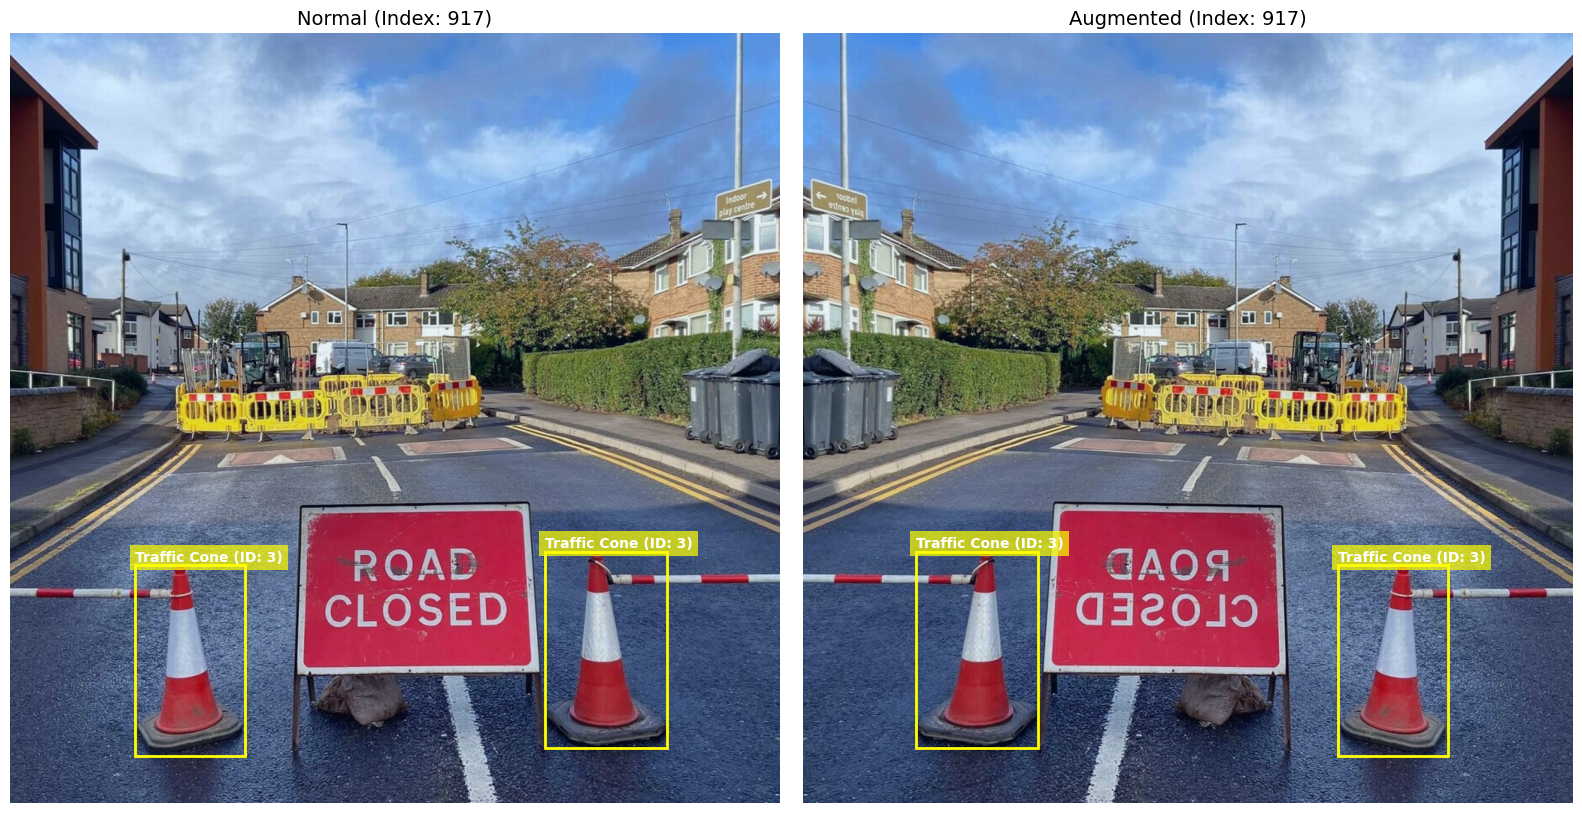

In [ ]:
def visualize_augmentation_comparison(raw_dataset, idx=None):
    if idx is None:
        idx = random.randint(0, len(raw_dataset) - 1)

    # Create two datasets: one normal, one augmented
    ds_normal = RTDETRDataset(raw_dataset, augment=False)
    ds_aug    = RTDETRDataset(raw_dataset, augment=True)

    # Fetch the same sample from both
    sample_normal = ds_normal[idx]
    sample_aug    = ds_aug[idx]

    # Setup Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Color mapping for each class
    color_map = {
        0: '#00FF00',  # green (Excavator)
        1: '#FF00FF',  # magenta (Pillar)
        2: '#FF4500',  # orange-red (Rock)
        3: '#FFFF00',  # yellow (Traffic Cone)
        4: '#00FFFF'   # cyan (Truck)
    }

    # Helper to draw boxes
    def draw_sample(ax, sample, title):
        # Prepare Image
        img_tensor = sample["pixel_values"]
        # (C, H, W) -> (H, W, C)
        img_np = img_tensor.permute(1, 2, 0).numpy()

        # Denormalize if necessary (simple min-max scaling for display)
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

        height, width, _ = img_np.shape
        ax.imshow(img_np)

        # Prepare Boxes
        boxes = sample["labels"]["boxes"]
        class_ids = sample["labels"]["class_labels"]

        for i, box in enumerate(boxes):
            coords = box.numpy()

            # Check if coordinates are normalized (0-1) or absolute pixels
            if coords.max() <= 1.0:
                # Assume format is [cx, cy, w, h] normalized
                cx, cy, w, h = coords

                # Convert to absolute [x1, y1, w, h] for plotting
                w_abs = w * width
                h_abs = h * height
                x1 = (cx * width) - (w_abs / 2)
                y1 = (cy * height) - (h_abs / 2)
            else:
                # Assume format is [x1, y1, x2, y2] absolute
                x1, y1, x2, y2 = coords
                w_abs = x2 - x1
                h_abs = y2 - y1

            # Get color for this class
            class_id = class_ids[i].item()
            box_color = color_map.get(class_id, '#FFFFFF')  # Default to white if class not found
            class_name = id2label.get(class_id, 'unknown')

            # Draw Box
            rect = patches.Rectangle(
                (x1, y1), w_abs, h_abs,
                linewidth=2, edgecolor=box_color, facecolor='none'
            )
            ax.add_patch(rect)

            # Draw Label with class name and ID
            ax.text(
                x1, y1 - 5, f"{class_name} (ID: {class_id})",
                color='white', fontsize=10, weight='bold',
                bbox=dict(facecolor=box_color, alpha=0.7, edgecolor='none')
            )

        ax.set_title(title, fontsize=14)
        ax.axis('off')

    # Draw both
    draw_sample(axes[0], sample_normal, f"Normal (Index: {idx})")
    draw_sample(axes[1], sample_aug,    f"Augmented (Index: {idx})")

    plt.tight_layout()
    plt.show()

# Run the comparison
# Pass your raw Hugging Face dataset 'train_ds' here
print("Visualizing Normal vs Augmented...")
visualize_augmentation_comparison(train_ds)


4. Load Data

In [ ]:
from torch.utils.data import DataLoader

Collate Function

In [ ]:
def custom_collate_fn(batch):
    images = []
    targets = []

    # Extract the actual tensors and dictionaries using their keys
    for item in batch:
        images.append(item["pixel_values"])  # Get the image tensor
        targets.append(item["labels"])       # Get the target dictionary

    # Stack the images into [Batch_Size, 3, 1024, 1024]
    batched_images = torch.stack(images, dim=0)

    # Leave targets as a list of dictionaries
    batched_targets = targets

    return batched_images, batched_targets

Data Loader

In [ ]:
train_dataset = RTDETRDataset(train_ds, augment=True, img_size=(1024, 1024))
val_dataset = RTDETRDataset(val_ds, augment=False, img_size=(1024, 1024))
test_dataset = RTDETRDataset(test_ds, augment=False, img_size=(1024, 1024))

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    collate_fn=custom_collate_fn,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    collate_fn=custom_collate_fn,
    pin_memory=True
)

print("Testing DataLoader...")
for batch_images, batch_targets in train_loader:
    print(f"Image Tensor Shape: {batch_images.shape}")

    # Expected output: 8 (matching the batch size)
    print(f"Number of Target Dictionaries: {len(batch_targets)}")

    # Inspect the targets of the first image in the batch
    print(f"Labels in first image: {batch_targets[0]['class_labels']}")
    print(f"Boxes in first image : \n{batch_targets[0]['boxes']}")
    break # Stop after inspecting just 1 batch

C:\Users\pengguna\AppData\Local\Temp\ipykernel_24360\1150686553.py:22: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=64, max_width=64, min_holes=1, p=0.3),


Testing DataLoader...
Image Tensor Shape: torch.Size([8, 3, 1024, 1024])
Number of Target Dictionaries: 8
Labels in first image: tensor([3])
Boxes in first image : 
tensor([[0.4692, 0.5418, 0.3370, 0.2740]])


5. Training

Hyperparameters

In [ ]:
NUM_EPOCHS = 300
WEIGHT_DECAY = 5e-4
patience = 30
best_val_loss = float('inf')
counter = 0
GRAD_ACCUMULATION_STEPS = 4

Differential Learning Rates

In [ ]:
# Different LR for backbone and decoder (Transformer Head)
LEARNING_RATE = 1e-4          # For the Transformer Head
BACKBONE_LR = 1e-5            # Protects the pre-trained backbone weights

param_dicts = [
    {
        "params": [p for n, p in model.named_parameters() if "backbone" not in n and p.requires_grad],
        "lr": LEARNING_RATE,
    },
    {
        "params": [p for n, p in model.named_parameters() if "backbone" in n and p.requires_grad],
        "lr": BACKBONE_LR,
    },
]

Optimizer

In [ ]:
# AdamW standard for RT-DETR
# Determines how the model changes its weights to minimize the error
optimizer = optim.AdamW(param_dicts, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler('cuda')

Scheduler

In [ ]:
# Scheduler (Cosine Annealing)
# Decrease LR smoothly from initial value to a minimum (1e-6) over the course of training
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

print(f"Starting training for {NUM_EPOCHS} epochs with Accumulation={GRAD_ACCUMULATION_STEPS}...")

Starting training for 300 epochs with Accumulation=4...


Training & Validation Loop

In [ ]:
# Training Loop
for epoch in range(NUM_EPOCHS):
    start_time = time.time()
    model.train()
    running_loss = 0.0

    optimizer.zero_grad()

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=True)

    for i, (batch_images, batch_targets) in enumerate(train_loop): # <--- FIXED UNPACKING

        # 1. Move Data to GPU
        pixel_values = batch_images.to(device)
        batch_size, _, height, width = pixel_values.shape
        pixel_mask = torch.ones((batch_size, height, width), dtype=torch.bool, device=device)

        # Safely move dictionaries to GPU
        targets = [{k: v.to(device) for k, v in t.items()} for t in batch_targets]

        # 2. Forward Pass
        with torch.amp.autocast('cuda'):
            outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=targets)
            loss = outputs.loss
            loss = loss / GRAD_ACCUMULATION_STEPS

        # 3. Backward
        scaler.scale(loss).backward()

        # 4. Step Optimizer (FIXED: Added condition for the final batch)
        if (i + 1) % GRAD_ACCUMULATION_STEPS == 0 or (i + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        # Update Metrics
        current_loss = loss.item() * GRAD_ACCUMULATION_STEPS
        running_loss += current_loss
        train_loop.set_postfix(loss=f"{current_loss:.4f}")

    avg_train_loss = running_loss / len(train_loader)

    # Validation Loop
    model.eval()
    val_loss = 0.0

    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val  ]", leave=True)

    with torch.no_grad():
        for batch_images, batch_targets in val_loop: # <--- FIXED UNPACKING

            pixel_values = batch_images.to(device)
            batch_size, _, height, width = pixel_values.shape
            pixel_mask = torch.ones((batch_size, height, width), dtype=torch.bool, device=device)

            targets = [{k: v.to(device) for k, v in t.items()} for t in batch_targets]

            with torch.amp.autocast('cuda'):
                outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=targets)
                loss = outputs.loss

            val_loss += loss.item()
            val_loop.set_postfix(loss=f"{loss.item():.4f}")

    avg_val_loss = val_loss / len(val_loader)

    # Logging
    epoch_duration = (time.time() - start_time) / 60
    print(f"\nSummary Epoch {epoch+1}:")
    print(f"   Time: {epoch_duration:.1f} min")
    print(f"   Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # Save Best Model & Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), "best_rt_detr_model.pth")
        print("   >>> Model Improved & Saved!")
    else:
        counter += 1
        print(f"   >>> No improvement. Counter: {counter}/{patience}")
        if counter >= patience:
            print("   >>> Early Stopping Triggered.")
            break

    # Step the scheduler at the end of the epoch
    scheduler.step()

    # Print LR (Targeting the main learning rate group)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"   Current LR: {current_lr:.6e}\n")

Epoch 1/300 [Val  ]: 100%|██████████| 36/36 [00:16<00:00,  2.17it/s, loss=20.1439]



Summary Epoch 1:
   Time: 1.8 min
   Train Loss: 112.8299 | Val Loss: 26.2809
   >>> Model Improved & Saved!
   Current LR: 9.999729e-05



Epoch 2/300 [Val  ]: 100%|██████████| 36/36 [00:14<00:00,  2.44it/s, loss=9.9606] 



Summary Epoch 2:
   Time: 1.7 min
   Train Loss: 22.0001 | Val Loss: 10.6335
   >>> Model Improved & Saved!
   Current LR: 9.998914e-05



Epoch 3/300 [Val  ]: 100%|██████████| 36/36 [00:14<00:00,  2.42it/s, loss=8.7047] 


...


Summary Epoch 78:
   Time: 1.7 min
   Train Loss: 5.7938 | Val Loss: 4.8095
   >>> No improvement. Counter: 28/30
   Current LR: 8.438508e-05



Epoch 79/300 [Val  ]: 100%|██████████| 36/36 [00:14<00:00,  2.43it/s, loss=6.0281]



Summary Epoch 79:
   Time: 1.7 min
   Train Loss: 5.8738 | Val Loss: 4.7407
   >>> No improvement. Counter: 29/30
   Current LR: 8.400536e-05



Epoch 80/300 [Val  ]: 100%|██████████| 36/36 [00:14<00:00,  2.41it/s, loss=6.1939]


Summary Epoch 80:
   Time: 1.7 min
   Train Loss: 6.0292 | Val Loss: 4.7449
   >>> No improvement. Counter: 30/30
   >>> Early Stopping Triggered.


6. Visualize

Configuration

In [ ]:
model_filename = r"D:\Skripsi_Raphaela\rt_detr\program\best_rt_detr_model.pth"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Updated Class mapping for your specific dataset
CLASS_MAP = {
    0: "Excavator",
    1: "Pillar",
    2: "Rock",
    3: "Traffic Cone",
    4: "Truck"
}

# Updated Color mapping
COLOR_MAP = {
    0: '#00FF00',  # Green
    1: '#FF00FF',  # Magenta
    2: '#FF4500',  # Orange-red
    3: '#FFFF00',  # Yellow
    4: '#00FFFF'   # Cyan
}

# Per Class Thresholds
PER_CLASS_THRESHOLDS = {
    0: 0.06,  # Excavator
    1: 0.03,  # Pillar
    2: 0.04,  # Rock
    3: 0.05,  # Traffic Cone
    4: 0.05   # Truck
}


Load Model

In [ ]:
print(f"Loading model: {model_filename} ...")

try:
    model = RTDetrForObjectDetection.from_pretrained(
        "PekingU/rtdetr_r18vd",
        id2label=CLASS_MAP,
        ignore_mismatched_sizes=True
    )

    # Load custom trained weights
    checkpoint = torch.load(model_filename, map_location=device)
    model.load_state_dict(checkpoint)
    model.to(device)
    model.eval()
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    model = None

Loading model: D:\Skripsi_Raphaela\rt_detr\program\best_rt_detr_model.pth ...


Loading weights: 100%|██████████| 526/526 [00:00<00:00, 1354.69it/s, Materializing param=model.encoder_input_proj.2.1.weight]                                                 
RTDetrForObjectDetection LOAD REPORT from: PekingU/rtdetr_r18vd
Key                                        | Status   |                                                                                        
-------------------------------------------+----------+----------------------------------------------------------------------------------------
model.enc_score_head.bias                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([5])          
model.decoder.class_embed.{0, 1, 2}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([5, 256])
model.decoder.class_embed.{0, 1, 2}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([5])          
model.denoising_class_embed.weight       

Model loaded successfully.


Prediction & Plotting Logic

In [ ]:
def predict_and_plot_adaptive(dataset, index=None, class_thresholds=PER_CLASS_THRESHOLDS):
    if model is None:
        print("Model not loaded.")
        return

    if index is None:
        index = random.randint(0, len(dataset) - 1)

    print(f"--- Debugging Image Index: {index} ---")

    sample = dataset[index]
    pixel_values = sample["pixel_values"].unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)

    prob = outputs.logits.sigmoid()
    scores, labels = prob.max(-1)

    cpu_scores = scores[0].cpu().numpy()
    cpu_labels = labels[0].cpu().numpy()
    cpu_boxes = outputs.pred_boxes[0].cpu().numpy()

    # --- Prepare Image ---
    image_np = sample["pixel_values"].permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image_np = std * image_np + mean
    image_np = np.clip(image_np, 0, 1)

    h_img, w_img, _ = image_np.shape

    # --- PADDING DETECTION & CLIPPING LOGIC ---
    # Detect padding color from the top-left pixel
    pad_color = image_np[0, 0, :]

    # Create a mask of the actual image area
    is_not_padding = ~np.all(np.isclose(image_np, pad_color, atol=0.05), axis=-1)
    rows, cols = np.where(is_not_padding)

    if rows.size > 0 and cols.size > 0:
        valid_y_min, valid_y_max = rows.min(), rows.max()
        valid_x_min, valid_x_max = cols.min(), cols.max()
    else:
        # Fallback if padding detection fails
        valid_y_min, valid_y_max = 0, h_img
        valid_x_min, valid_x_max = 0, w_img

    fig, ax = plt.subplots(1, figsize=(12, 12))
    ax.imshow(image_np)

    # --- Plot Ground Truth (Dashed Lines) ---
    gt_boxes = sample["labels"]["boxes"].cpu().numpy()
    gt_classes = sample["labels"]["class_labels"].cpu().numpy()

    for box, cls_id in zip(gt_boxes, gt_classes):
        cx, cy, bw, bh = box

        # Convert relative (0-1) to absolute pixels
        x1 = (cx - bw/2) * w_img
        y1 = (cy - bh/2) * h_img
        x2 = x1 + (bw * w_img)
        y2 = y1 + (bh * h_img)

        # Clip GT boxes to valid area
        x1_c = np.clip(x1, valid_x_min, valid_x_max)
        y1_c = np.clip(y1, valid_y_min, valid_y_max)
        x2_c = np.clip(x2, valid_x_min, valid_x_max)
        y2_c = np.clip(y2, valid_y_min, valid_y_max)

        if (x2_c - x1_c) > 1 and (y2_c - y1_c) > 1:
            box_color = COLOR_MAP.get(cls_id, '#FFFFFF')
            rect = patches.Rectangle((x1_c, y1_c), x2_c - x1_c, y2_c - y1_c, linewidth=2, edgecolor=box_color, facecolor='none', linestyle='--')
            ax.add_patch(rect)
            ax.text(x1_c, y1_c-5, f"GT: {CLASS_MAP.get(cls_id, str(cls_id))}", color=box_color, fontsize=8, weight='bold', bbox=dict(facecolor='black', alpha=0.5))

    # Plot Predictions with ADAPTIVE THRESHOLD & PADDING CLIP
    drawn_count = 0
    print("\nEvaluation Results (Adaptive Thresholds & Padding Removed):")
    print(f"{'Class':<15} | {'Raw Score':<9} | {'Threshold':<9} | {'Norm Score':<10} | {'Status'}")
    print("-" * 68)

    indices = np.argsort(cpu_scores)[::-1]

    # Check top 20 predictions
    for i in indices[:20]:
        score = cpu_scores[i]
        label_idx = cpu_labels[i]
        box = cpu_boxes[i]
        cls_id = int(label_idx)
        cls_name = CLASS_MAP.get(cls_id, str(cls_id))

        required_conf = class_thresholds.get(cls_id, 0.05)

        max_raw_score = 0.40
        normalized_score = np.interp(score, [required_conf, max_raw_score], [0.75, 0.99])

        if score >= required_conf:
            # Calculate coordinates
            cx, cy, bw, bh = box
            x1 = (cx - bw/2) * w_img
            y1 = (cy - bh/2) * h_img
            x2 = x1 + (bw * w_img)
            y2 = y1 + (bh * h_img)

            # --- CLIPPING LOGIC ---
            x1_clipped = max(valid_x_min, x1)
            y1_clipped = max(valid_y_min, y1)
            x2_clipped = min(valid_x_max, x2)
            y2_clipped = min(valid_y_max, y2)

            original_area = (x2 - x1) * (y2 - y1)
            clipped_area = (x2_clipped - x1_clipped) * (y2_clipped - y1_clipped)

            is_valid_box = (clipped_area > 0) and (clipped_area / (original_area + 1e-6) > 0.5)

            if is_valid_box:
                status = "VALID ✅"
                drawn_count += 1
                box_color = COLOR_MAP.get(cls_id, '#00FF00')

                # Draw Solid Box
                rect = patches.Rectangle((x1_clipped, y1_clipped), x2_clipped - x1_clipped, y2_clipped - y1_clipped, linewidth=3, edgecolor=box_color, facecolor='none')
                ax.add_patch(rect)

                # Format label text
                label_text = f"{cls_name}: {normalized_score:.2f}"
                ax.text(x1_clipped, y1_clipped - 5, label_text, color='black', fontsize=9, weight='bold', bbox=dict(facecolor=box_color, alpha=0.8, edgecolor='none', pad=2))
            else:
                status = "Padding (Removed)"
        else:
            status = "Low Score (Ignored)"

        if score > 0.01:
            norm_str = f"{normalized_score:.2f}" if score >= required_conf else "-"
            print(f"{cls_name:<15} | {score:.4f}    | {required_conf:<9.2f} | {norm_str:<10} | {status}")

Visualization

--- Debugging Image Index: 224 ---

Evaluation Results (Adaptive Thresholds & Padding Removed):
Class           | Raw Score | Threshold | Norm Score | Status
--------------------------------------------------------------------
Traffic Cone    | 0.1739    | 0.05      | 0.83       | VALID ✅
Rock            | 0.0372    | 0.04      | -          | Low Score (Ignored)
Traffic Cone    | 0.0261    | 0.05      | -          | Low Score (Ignored)
Pillar          | 0.0250    | 0.03      | -          | Low Score (Ignored)
Pillar          | 0.0248    | 0.03      | -          | Low Score (Ignored)
Rock            | 0.0247    | 0.04      | -          | Low Score (Ignored)
Traffic Cone    | 0.0244    | 0.05      | -          | Low Score (Ignored)
Traffic Cone    | 0.0217    | 0.05      | -          | Low Score (Ignored)
Pillar          | 0.0214    | 0.03      | -          | Low Score (Ignored)
Pillar          | 0.0206    | 0.03      | -          | Low Score (Ignored)
Pillar          | 0.0192    | 0.03 

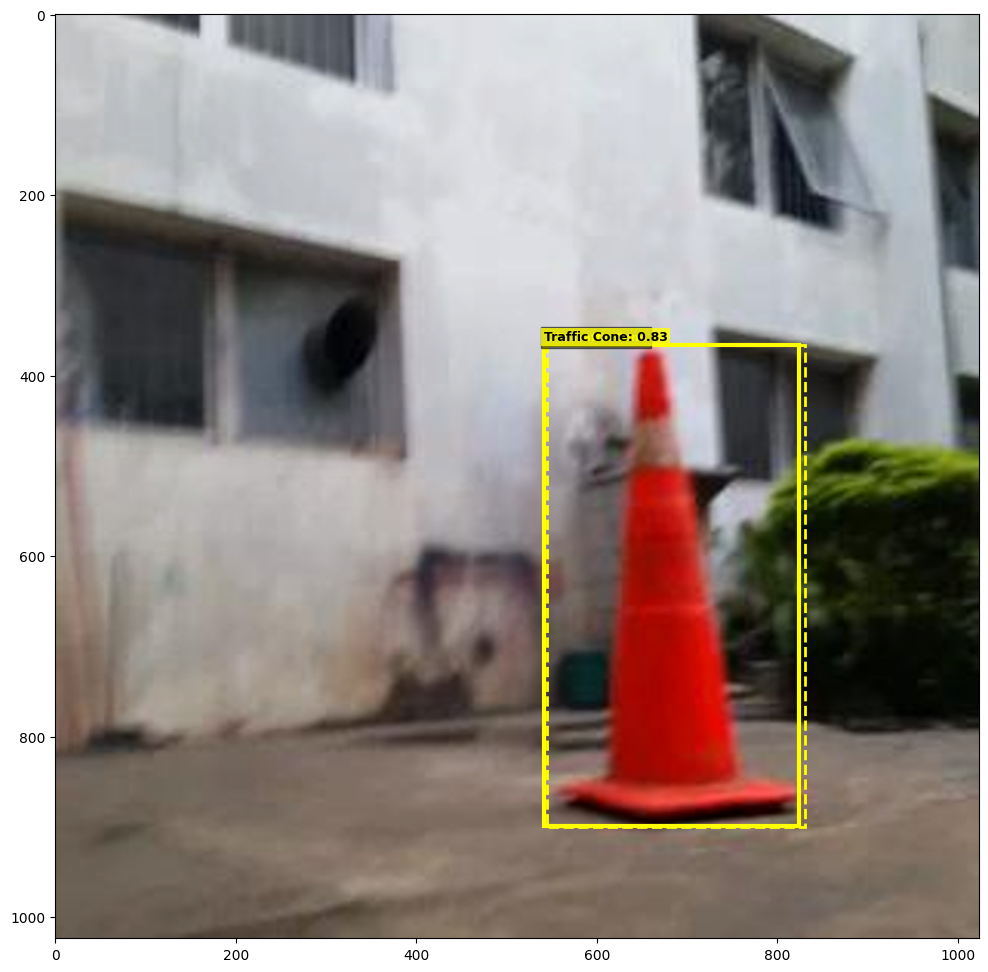

In [ ]:

predict_and_plot_adaptive(val_dataset)

Matrix Evaluation

Generating Confusion Matrix on cuda...


  0%|          | 0/288 [00:00<?, ?it/s]C:\Users\pengguna\AppData\Local\Temp\ipykernel_24360\3332850364.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pixel_values = torch.tensor(element["pixel_values"]).unsqueeze(0).to(device)
C:\Users\pengguna\AppData\Local\Temp\ipykernel_24360\3332850364.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gt_boxes = torch.tensor(labels["boxes"])
100%|██████████| 288/288 [00:16<00:00, 17.69it/s]


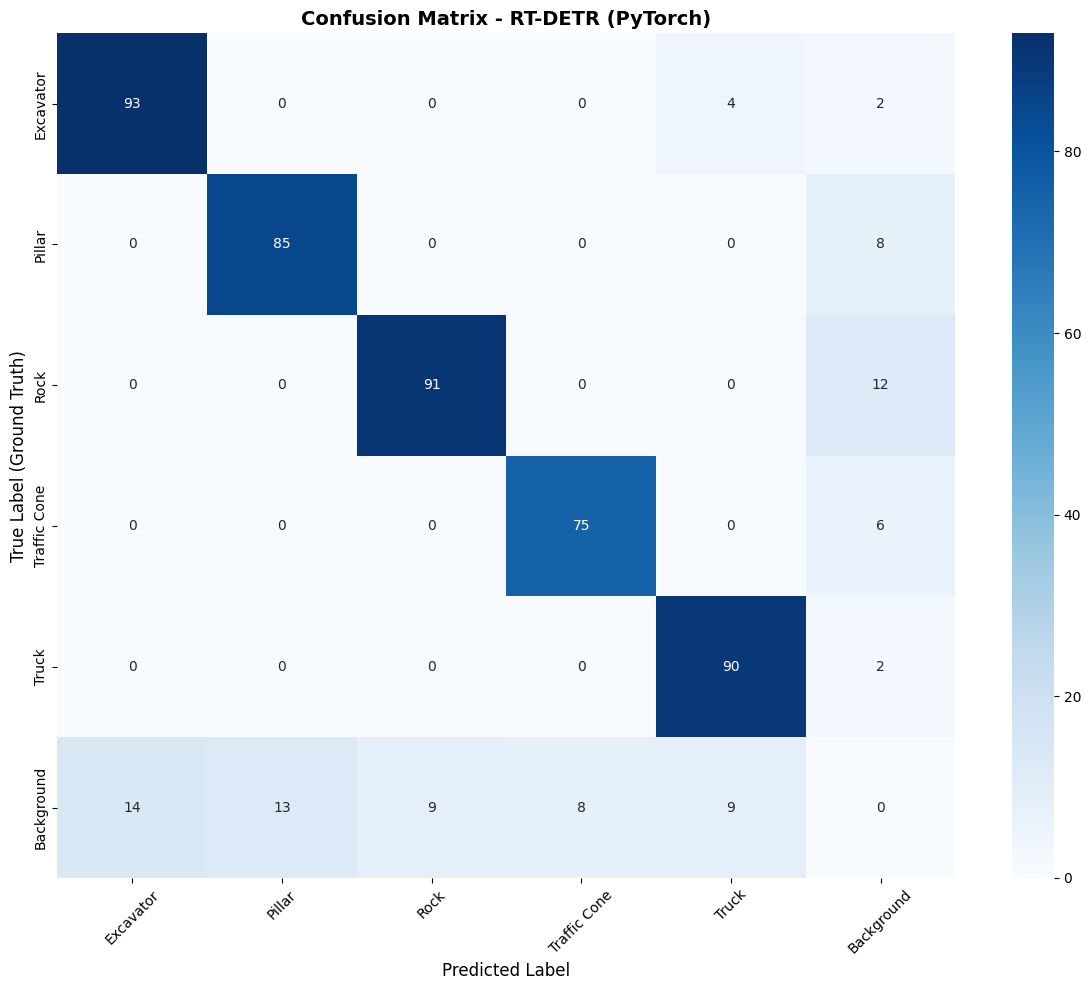


Classification Report:
              precision    recall  f1-score   support

   Excavator       0.87      0.94      0.90        99
      Pillar       0.87      0.91      0.89        93
        Rock       0.91      0.88      0.90       103
Traffic Cone       0.90      0.93      0.91        81
       Truck       0.87      0.98      0.92        92
  Background       0.00      0.00      0.00        53

    accuracy                           0.83       521
   macro avg       0.74      0.77      0.75       521
weighted avg       0.79      0.83      0.81       521



In [ ]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
from torchvision.ops import box_iou, box_convert

def get_confusion_matrix_rtdetr(model, processor, dataset, device, threshold=0.1, iou_threshold=0.3):
    model.eval()
    all_true_labels = []
    all_pred_labels = []

    # Retrieve class names and dynamically add 'Background'
    CLASSES = [id2label[i] for i in range(len(id2label))] + ["Background"]
    BG_CLASS_ID = len(id2label) # Background ID is the next available integer

    print(f"Generating Confusion Matrix on {device}...")

    for element in tqdm(dataset):
        # 1. Prepare Input
        pixel_values = torch.tensor(element["pixel_values"]).unsqueeze(0).to(device)
        labels = element["labels"] # Ground Truth

        # 2. Model Inference
        with torch.no_grad():
            outputs = model(pixel_values=pixel_values)

        # 3. Post-Processing Predictions
        target_sizes = torch.tensor([pixel_values.shape[-2:]])
        results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=threshold)[0]

        pred_boxes = results["boxes"].cpu()
        pred_labels = results["labels"].cpu().tolist()

        # 4. Prepare Ground Truth Boxes
        gt_boxes = torch.tensor(labels["boxes"])
        gt_labels = labels["class_labels"].tolist()

        if gt_boxes.shape[0] > 0:
            # Rescale GT boxes from normalized [0, 1] to pixel values
            img_h, img_w = target_sizes[0]
            gt_boxes[:, [0, 2]] *= img_w
            gt_boxes[:, [1, 3]] *= img_h

            # Convert GT from [cx, cy, w, h] to [x1, y1, x2, y2]
            gt_boxes = box_convert(gt_boxes, 'cxcywh', 'xyxy')

        # 5. KEY FIX: Matching logic incorporating Background
        if len(pred_boxes) > 0 and len(gt_boxes) > 0:
            iou_matrix = box_iou(gt_boxes, pred_boxes)
            matched_pred_indices = set()

            for i, gt_label in enumerate(gt_labels):
                ious = iou_matrix[i]
                max_iou, max_idx = torch.max(ious, dim=0)

                if max_iou >= iou_threshold:
                    # True Positive or Misclassification between objects
                    all_true_labels.append(gt_label)
                    all_pred_labels.append(pred_labels[max_idx.item()])
                    matched_pred_indices.add(max_idx.item())
                else:
                    # False Negative (Missed detection)
                    all_true_labels.append(gt_label)
                    all_pred_labels.append(BG_CLASS_ID)

            # False Positive (Hallucinated detection)
            for j, pred_label in enumerate(pred_labels):
                if j not in matched_pred_indices:
                    all_true_labels.append(BG_CLASS_ID)
                    all_pred_labels.append(pred_label)

        elif len(gt_boxes) > 0 and len(pred_boxes) == 0:
            # Model predicted nothing, all GTs are False Negatives
            for gt_label in gt_labels:
                all_true_labels.append(gt_label)
                all_pred_labels.append(BG_CLASS_ID)

        elif len(pred_boxes) > 0 and len(gt_boxes) == 0:
            # Ground truth is empty, all Predictions are False Positives
            for pred_label in pred_labels:
                all_true_labels.append(BG_CLASS_ID)
                all_pred_labels.append(pred_label)

    if len(all_true_labels) == 0:
        print("❌ Error: No matches found. Matrix cannot be generated.")
        return

    # 6. Generate Plot
    cm = confusion_matrix(all_true_labels, all_pred_labels, labels=list(range(len(CLASSES))))

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label (Ground Truth)', fontsize=12)
    plt.title('Confusion Matrix - RT-DETR (PyTorch)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 7. Print Text Report
    print("\nClassification Report:")
    print(classification_report(all_true_labels, all_pred_labels,
                                target_names=CLASSES, labels=list(range(len(CLASSES))),
                                zero_division=0))

# Execution
device = "cuda" if torch.cuda.is_available() else "cpu"
get_confusion_matrix_rtdetr(model, processor, val_dataset, device=device, threshold=0.1, iou_threshold=0.3)

Loss Curve

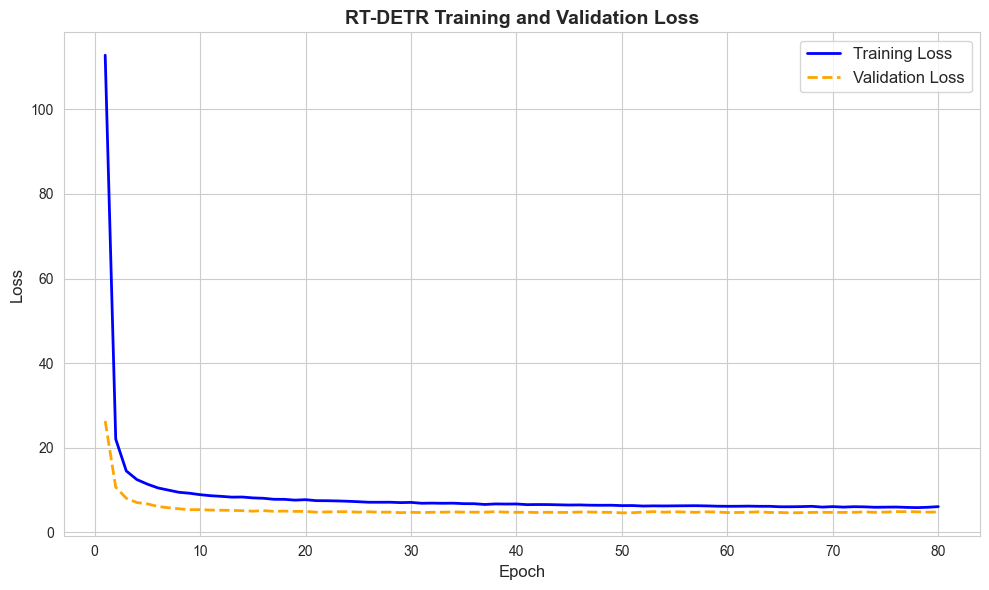

Successfully extracted data from 80 Epochs!


In [ ]:
notebook_path = r"D:\Skripsi_Raphaela\rt_detr\program\train_rtdetr.ipynb"

# Parse JSON structure of the notebook
with open(notebook_path, 'r', encoding='utf-8') as f:
    nb_data = json.load(f)

train_losses = []
val_losses = []
epochs = []

# Find the cell containing the training loop and extract the Loss values
for cell in nb_data.get('cells', []):
    if cell.get('cell_type') == 'code':
        source = "".join(cell.get('source', []))

        # Look for the specific training loop cell
        if "NUM_EPOCHS" in source and "for epoch in" in source:
            outputs = cell.get('outputs', [])
            extracted_text = ""
            for out in outputs:
                if 'text' in out:
                    extracted_text += "".join(out['text'])

            # Use Regex to extract Train and Val Loss numbers from the output text
            matches = re.findall(r'Train Loss:\s*([0-9.]+)\s*\|\s*Val Loss:\s*([0-9.]+)', extracted_text)
            for idx, match in enumerate(matches):
                train_losses.append(float(match[0]))
                val_losses.append(float(match[1]))
                epochs.append(idx + 1)
            break

# Generate the Loss Curve Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Plot the lines
plt.plot(epochs, train_losses, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs, val_losses, label='Validation Loss', color='orange', linewidth=2, linestyle='--')

# Configure labels and title
plt.title('RT-DETR Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()

# Save the image to your local directory (High resolution for thesis document)
plt.savefig('loss_curve_chapter4.png', dpi=300)

# Display the plot
plt.show()

print(f"Successfully extracted data from {len(epochs)} Epochs!")